# Count Prediction Modeling for Asthma Exacerbations

In the previous notebooks, I converted the original count outcome into a binary outcome and modeled whether a patient had at least one post-index exacerbation.

However, the original target variable is `post_index_exacerbations365`, which records the number of asthma exacerbations during the year after treatment start.

In this notebook, I will return to the original count outcome and build models to predict the number of exacerbations.

Because the target variable is zero-heavy and right-skewed, I will compare simple regression models with count-aware modeling approaches.

## Modeling Plan

In this notebook, I will:

1. Load the processed train-test datasets.
2. Load the original count target files.
3. Build a dummy baseline model.
4. Build a linear regression model.
5. Build a Poisson regression model.
6. Build a Random Forest regression model.
7. Compare models using regression and count-prediction metrics.
8. Interpret whether count prediction is easier or harder than binary classification.

The main evaluation metrics will include:

- Mean Absolute Error, MAE
- Root Mean Squared Error, RMSE
- R² score
- Mean Poisson deviance, when predictions are valid for that metric

In [1]:
# Importing libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, PoissonRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_poisson_deviance
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid")


## Load Processed Data

I will use the same processed log-charge feature set created in the preprocessing notebook.

The feature files are:

- `X_train_log.csv`
- `X_test_log.csv`

The count target files are:

- `y_count_train.csv`
- `y_count_test.csv`

Using the same train-test split allows comparison between the binary classification and count prediction tasks.


In [2]:
# Loading data

X_train = pd.read_csv("../data/processed/X_train_log.csv")
X_test = pd.read_csv("../data/processed/X_test_log.csv")

y_train = pd.read_csv("../data/processed/y_count_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_count_test.csv").squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (14572, 16)
X_test shape: (3643, 16)
y_train shape: (14572,)
y_test shape: (3643,)


In [4]:
# To check  of Count Target 

count_target_summary = pd.DataFrame({
    "train": y_train.describe(),
    "test": y_test.describe()
})

count_target_summary



,train,test
count,14572.0000,3643.0000
mean,0.1732,0.1803
std,0.6242,0.6687
min,0.0000,0.0000
25%,0.0000,0.0000
50%,0.0000,0.0000
75%,0.0000,0.0000
max,13.0000,14.0000


In [5]:
y_train.value_counts().sort_index()

post_index_exacerbations365
0     12899
1      1225
2       269
3        88
4        36
5        25
6         9
7         8
8         7
9         3
10        1
12        1
13        1
Name: count, dtype: int64

In [6]:
y_test.value_counts().sort_index()

post_index_exacerbations365
0     3225
1      300
2       64
3       27
4       12
5        7
6        3
7        1
8        2
10       1
14       1
Name: count, dtype: int64

## Count Target Reminder

The count target is highly concentrated at zero. Most patients had no exacerbations during the post-index year, while a much smaller number had one or more events.

This zero-heavy distribution is important because a model may achieve a low average error by predicting values close to zero for most patients. Therefore, I need to evaluate whether the model is actually learning useful signal beyond the baseline.


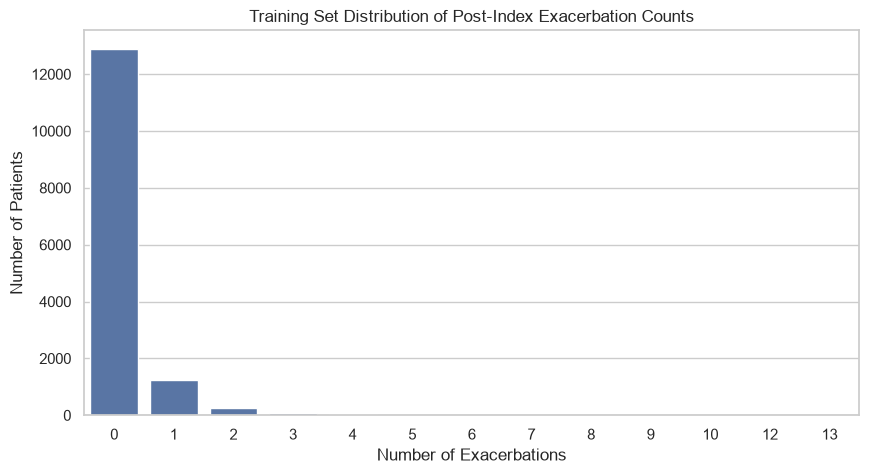

In [7]:
# Plotting distribution of Target

plt.figure(figsize=(10, 5))

sns.countplot(
    x=y_train,
    order=sorted(y_train.unique())
)

plt.title("Training Set Distribution of Post-Index Exacerbation Counts")
plt.xlabel("Number of Exacerbations")
plt.ylabel("Number of Patients")
plt.show()


## Regression Evaluation Function

To compare count prediction models consistently, I will define a helper function.

The main metrics are:

- **MAE:** average absolute prediction error.
- **RMSE:** square-root of the average squared error; penalizes large errors more strongly.
- **R²:** proportion of variance explained by the model.
- **Mean Poisson deviance:** useful for count outcomes when predictions are non-negative.

Because exacerbation counts are small and zero-heavy, MAE may be easier to interpret than RMSE or R².


In [8]:
# Evaluation Function
#
def evaluate_regressor(model_name, y_true, y_pred):
    """
    Evaluate regression/count prediction model.
    Predictions are clipped at zero for count-compatible metrics.
    """
    
    y_pred_clipped = np.clip(y_pred, 0, None)
    
    results = {
        "model": model_name,
        "mae": mean_absolute_error(y_true, y_pred_clipped),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred_clipped)),
        "r2": r2_score(y_true, y_pred_clipped)
    }
    
    # Mean Poisson deviance requires non-negative predictions.
    # Predictions also cannot be exactly zero when y_true has positive values.
    y_pred_poisson = np.clip(y_pred_clipped, 1e-8, None)
    results["mean_poisson_deviance"] = mean_poisson_deviance(y_true, y_pred_poisson)
    
    return pd.DataFrame([results])


## Model 1- Baseline Model: Dummy Regressor

Before fitting machine learning models, I will create a simple dummy regression baseline.

The dummy model predicts the average number of exacerbations from the training set for every patient.

This gives a basic reference point. Any useful model should perform better than this baseline.

In [9]:
# Dummy regressor

dummy_reg = DummyRegressor(strategy="mean")

dummy_reg.fit(X_train, y_train)

dummy_pred = dummy_reg.predict(X_test)

dummy_results = evaluate_regressor(
    model_name="Dummy Mean Regressor",
    y_true=y_test,
    y_pred=dummy_pred
)

dummy_results


,model,mae,rmse,r2,mean_poisson_deviance
0,Dummy Mean Regressor,0.3138,0.6686,-0.0001,0.8595


In [10]:
pd.Series(dummy_pred).describe()


count   3643.0000
mean       0.1732
std        0.0000
min        0.1732
25%        0.1732
50%        0.1732
75%        0.1732
max        0.1732
dtype: float64

## Model 2: Linear Regression

Linear regression is a simple baseline model for continuous prediction.

Although the outcome is a count variable, linear regression is useful as a reference model. However, it may produce negative predictions, which are not meaningful for count outcomes. For evaluation, I will clip negative predictions to zero.

In [11]:
# Linear regression 

linear_reg = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]
)

linear_reg.fit(X_train, y_train)

linear_pred = linear_reg.predict(X_test)

linear_results = evaluate_regressor(
    model_name="Linear Regression",
    y_true=y_test,
    y_pred=linear_pred
)

linear_results

,model,mae,rmse,r2,mean_poisson_deviance
0,Linear Regression,0.3108,0.6685,0.0004,0.8709


In [12]:
pd.Series(linear_pred).describe()

count   3643.0000
mean       0.1720
std        0.0545
min       -0.0252
25%        0.1383
50%        0.1711
75%        0.2061
max        0.4610
dtype: float64

## Model 2: Poisson Regression

Poisson regression is designed for non-negative count outcomes. Since the target variable is the number of asthma exacerbations, Poisson regression is a natural modeling approach to try.

Poisson regression predicts non-negative expected counts, which is more appropriate than linear regression for this type of outcome.

However, this dataset has many zeros and may be overdispersed, so Poisson regression may still have limitations.


In [13]:
# Poisson regressor

poisson_reg = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", PoissonRegressor(
            alpha=1.0,
            max_iter=1000
        ))
    ]
)

poisson_reg.fit(X_train, y_train)

poisson_pred = poisson_reg.predict(X_test)

poisson_results = evaluate_regressor(
    model_name="Poisson Regression",
    y_true=y_test,
    y_pred=poisson_pred
)

poisson_results


,model,mae,rmse,r2,mean_poisson_deviance
0,Poisson Regression,0.3132,0.6682,0.0011,0.8564


In [14]:
pd.Series(poisson_pred).describe()

count   3643.0000
mean       0.1730
std        0.0109
min        0.1370
25%        0.1657
50%        0.1725
75%        0.1796
max        0.2386
dtype: float64

## Model 4: Random Forest Regressor

Random Forest regression is a non-linear model that can capture interactions between predictors.

Unlike linear regression and Poisson regression, it does not require feature scaling. It may be able to model more complex relationships between baseline patient characteristics and future exacerbation counts.

However, because the outcome is highly zero-heavy, the model may still predict values close to zero for most patients.

In [15]:
# Rf

rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=5,
    random_state=22,
    n_jobs=-1
)

rf_reg.fit(X_train, y_train)

rf_pred = rf_reg.predict(X_test)

rf_results = evaluate_regressor(
    model_name="Random Forest Regressor",
    y_true=y_test,
    y_pred=rf_pred
)

rf_results


,model,mae,rmse,r2,mean_poisson_deviance
0,Random Forest Regressor,0.3134,0.6701,-0.0046,0.8611


In [16]:
pd.Series(rf_pred).describe()


count   3643.0000
mean       0.1739
std        0.0733
min        0.0719
25%        0.1241
50%        0.1624
75%        0.2070
max        1.4372
dtype: float64

In [17]:
# Now lets compare models

count_model_results = pd.concat(
    [
        dummy_results,
        linear_results,
        poisson_results,
        rf_results
    ],
    ignore_index=True
)

count_model_results.sort_values("mae")



,model,mae,rmse,r2,mean_poisson_deviance
1,Linear Regression,0.3108,0.6685,0.0004,0.8709
2,Poisson Regression,0.3132,0.6682,0.0011,0.8564
3,Random Forest Regressor,0.3134,0.6701,-0.0046,0.8611
0,Dummy Mean Regressor,0.3138,0.6686,-0.0001,0.8595


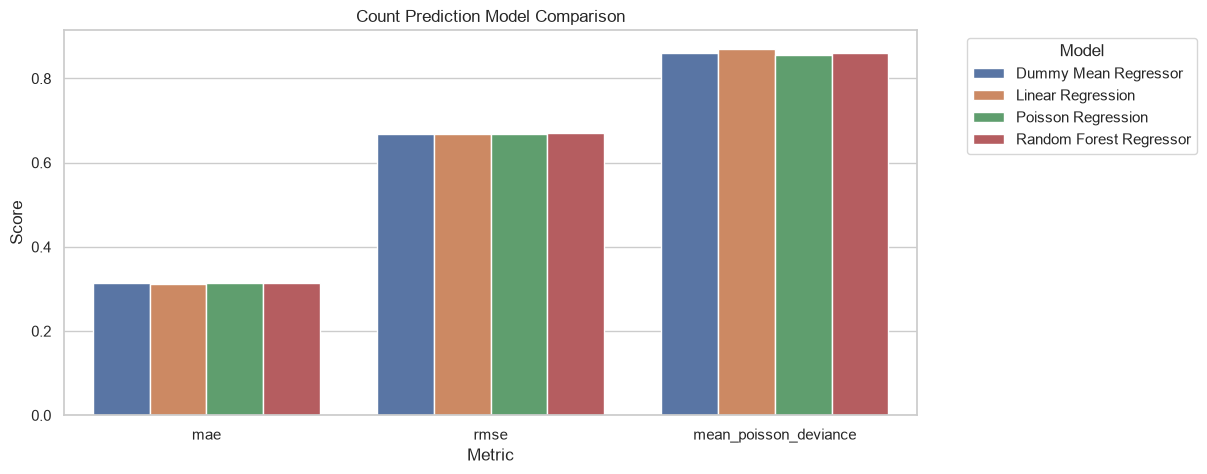

In [18]:
# Plotting Model Comparison

metrics_to_plot = ["mae", "rmse", "mean_poisson_deviance"]

count_results_long = count_model_results.melt(
    id_vars="model",
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(11, 5))

sns.barplot(
    data=count_results_long,
    x="metric",
    y="score",
    hue="model"
)

plt.title("Count Prediction Model Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


In [20]:
# Prediction vs Actual plot

prediction_comparison = pd.DataFrame({
    "actual": y_test,
    "dummy_pred": dummy_pred,
    "linear_pred": np.clip(linear_pred, 0, None),
    "poisson_pred": poisson_pred,
    "rf_pred": rf_pred
})

prediction_comparison.tail()


,actual,dummy_pred,linear_pred,poisson_pred,rf_pred
3638,0,0.1732,0.2108,0.1782,0.2246
3639,0,0.1732,0.2004,0.1786,0.1329
3640,0,0.1732,0.1899,0.1760,0.1857
3641,0,0.1732,0.2136,0.1783,0.3356
3642,0,0.1732,0.1912,0.1782,0.1289


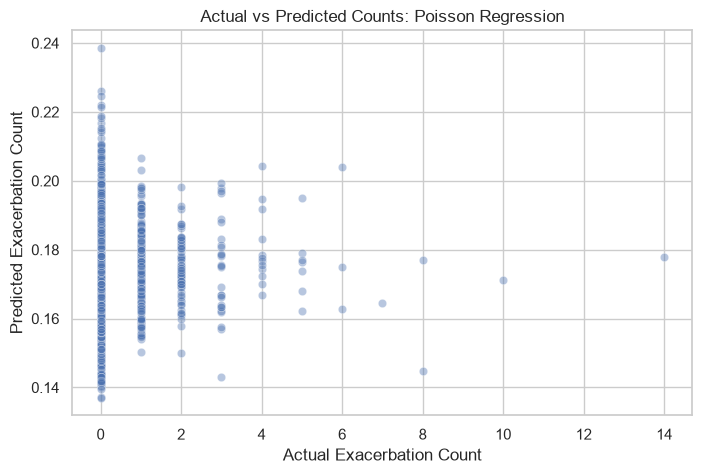

In [ ]:
# Prediction vs Actual count plot

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=prediction_comparison,
    x="actual",
    y="poisson_pred",
    alpha=0.4
)

plt.title("Actual vs Predicted Counts: Poisson Regression")
plt.xlabel("Actual Exacerbation Count")
plt.ylabel("Predicted Exacerbation Count")
plt.show()



## Observation: Count Prediction Model Comparison

The count prediction models performed very similarly to the dummy mean baseline.

The dummy model predicted the average exacerbation count for every patient and achieved an MAE of **0.3138**. Linear regression had the lowest MAE (**0.3108**), but the improvement over the dummy model was very small. Poisson regression had the best mean Poisson deviance (**0.8564**) and the highest R² (**0.0011**), but this improvement was also minimal.

The R² values were close to zero for all models, and Random Forest even had a slightly negative R². This suggests that the models explained very little variation in the exacerbation count outcome.

This result is not completely surprising because the target variable is highly zero-heavy. Most patients had zero exacerbations, and relatively few patients had one or more events. As a result, predicting values close to zero works reasonably well for average error metrics, but it does not necessarily mean the model is clinically useful.

Overall, the available predictors do not appear to provide strong signal for accurately predicting the exact number of exacerbations. Count prediction may be harder than the binary classification task in this dataset.


In [22]:
prediction_summary = pd.DataFrame({
    "dummy_pred": pd.Series(dummy_pred).describe(),
    "linear_pred": pd.Series(np.clip(linear_pred, 0, None)).describe(),
    "poisson_pred": pd.Series(poisson_pred).describe(),
    "rf_pred": pd.Series(rf_pred).describe()
})

prediction_summary


,dummy_pred,linear_pred,poisson_pred,rf_pred
count,3643.0000,3643.0000,3643.0000,3643.0000
mean,0.1732,0.1720,0.1730,0.1739
std,0.0000,0.0544,0.0109,0.0733
min,0.1732,0.0000,0.1370,0.0719
25%,0.1732,0.1383,0.1657,0.1241
50%,0.1732,0.1711,0.1725,0.1624
75%,0.1732,0.2061,0.1796,0.2070
max,0.1732,0.4610,0.2386,1.4372


## Observation: Prediction Distribution

The prediction summary shows that most models predicted values close to the average exacerbation count.

The dummy model predicted the same value, **0.1732**, for every patient. Linear regression and Poisson regression also produced predictions mostly close to zero. The Poisson regression predictions were especially narrow, ranging from about **0.1370** to **0.2386**.

This suggests that the models are mostly learning the overall low event rate rather than strongly distinguishing patients with higher exacerbation counts.

The Random Forest model produced a slightly wider range of predictions, with a maximum predicted value of about **1.44**, but its overall model performance was still not better than the simpler models.

This prediction pattern is important because average metrics such as MAE can look reasonable when most patients have zero events, even if the model does not perform well for patients with multiple exacerbations.


## Error Analysis by Actual Exacerbation Count

Average metrics such as MAE can hide important details. Since most patients have zero exacerbations, a model may perform well for the majority group but poorly for patients with multiple exacerbations.

To understand this better, I will examine prediction error by actual exacerbation count.

In [23]:
prediction_comparison = pd.DataFrame({
    "actual": y_test,
    "dummy_pred": dummy_pred,
    "linear_pred": np.clip(linear_pred, 0, None),
    "poisson_pred": poisson_pred,
    "rf_pred": rf_pred
})

prediction_comparison["poisson_abs_error"] = (
    prediction_comparison["actual"] - prediction_comparison["poisson_pred"]
).abs()

prediction_comparison.groupby("actual")["poisson_abs_error"].agg(
    count="count",
    mean_abs_error="mean"
)



,count,mean_abs_error
actual,,
0,3225,0.1728
1,300,0.8254
2,64,1.8254
3,27,2.8254
4,12,3.8195
5,7,4.8241
6,3,5.8193
7,1,6.8355
8,2,7.8391


## Observation: Error by Actual Exacerbation Count

The error analysis shows that Poisson regression performs much better for patients with zero exacerbations than for patients with one or more exacerbations.

For patients with **0 actual exacerbations**, the mean absolute error was about **0.17**. However, the error increased as the actual exacerbation count increased. For example, patients with **1 actual exacerbation** had an average error of about **0.83**, while patients with **2 actual exacerbations** had an average error of about **1.83**.

This pattern occurs because the model mostly predicts values close to the overall mean exacerbation count. Therefore, it performs reasonably for the majority group with zero events but underestimates patients with higher exacerbation counts.

This suggests that exact count prediction is difficult in this dataset, especially for patients with multiple exacerbations. A two-stage approach may be more meaningful later: first identifying whether a patient is likely to have any exacerbation, and then modeling the count among patients who have at least one event.


## Tuned Poisson Regression

Since Poisson regression is designed for count outcomes, I will tune the regularization parameter `alpha`.

The goal is to check whether a better regularization setting improves count prediction compared with the default Poisson model.

In [24]:
# Tuning Poisson Regressor

from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import make_scorer

cv_reg = KFold(
    n_splits=5,
    shuffle=True,
    random_state=22
)

poisson_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", PoissonRegressor(max_iter=1000))
    ]
)

poisson_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10]
}

# Use negative mean Poisson deviance because GridSearchCV maximizes scores
poisson_scorer = make_scorer(
    mean_poisson_deviance,
    greater_is_better=False
)

poisson_grid = GridSearchCV(
    estimator=poisson_pipeline,
    param_grid=poisson_param_grid,
    scoring=poisson_scorer,
    cv=cv_reg,
    n_jobs=-1,
    refit=True
)

poisson_grid.fit(X_train, y_train)

print("Best parameters:", poisson_grid.best_params_)
print("Best cross-validated negative mean Poisson deviance:", poisson_grid.best_score_)




Best parameters: {'model__alpha': 0.01}
Best cross-validated negative mean Poisson deviance: -0.8052545717277871


In [25]:
best_poisson = poisson_grid.best_estimator_

tuned_poisson_pred = best_poisson.predict(X_test)

tuned_poisson_results = evaluate_regressor(
    model_name="Tuned Poisson Regression",
    y_true=y_test,
    y_pred=tuned_poisson_pred
)

tuned_poisson_results



,model,mae,rmse,r2,mean_poisson_deviance
0,Tuned Poisson Regression,0.3108,0.6681,0.0015,0.8559


## Observation: Tuned Poisson Regression

After tuning the Poisson regression regularization parameter, the best value was:

- `alpha`: **0.01**

The tuned Poisson regression model achieved:

- MAE: **0.3108**
- RMSE: **0.6681**
- R²: **0.0015**
- Mean Poisson deviance: **0.8559**

This was the best mean Poisson deviance among the tested count prediction models. However, the improvement over the untuned Poisson model and dummy baseline was very small.

The R² value remained close to zero, which means the model explained very little variation in the exacerbation count outcome.

Overall, tuning improved the Poisson regression model slightly, but it did not solve the main challenge: the target variable is highly zero-heavy, and patients with multiple exacerbations are rare.

In [26]:
count_model_results_final = pd.concat(
    [
        count_model_results,
        tuned_poisson_results
    ],
    ignore_index=True
)

count_model_results_final.sort_values("mean_poisson_deviance")


,model,mae,rmse,r2,mean_poisson_deviance
4,Tuned Poisson Regression,0.3108,0.6681,0.0015,0.8559
2,Poisson Regression,0.3132,0.6682,0.0011,0.8564
0,Dummy Mean Regressor,0.3138,0.6686,-0.0001,0.8595
3,Random Forest Regressor,0.3134,0.6701,-0.0046,0.8611
1,Linear Regression,0.3108,0.6685,0.0004,0.8709
